# 09 – Forecast Models
## Wind Power Forecasting | Seminar WIBA

Dieses Notebook vergleicht alle Forecast-Modelle auf denselben Daten.

**Teil A – Point Forecasts** (klassisch: Features → Prediction)

| # | Modell | Typ |
|---|--------|-----|
| 1 | Persistence | Naiv |
| 2 | Mean Forecast | Naiv |
| 3 | Linear Regression | Interpretierbar |
| 4 | Elastic Net | Interpretierbar + Regularisierung |
| 5 | Random Forest | Tree-based ML |
| 6 | Neural Network (MLP) | Black Box |

**Teil B – Windowing-based ML** (Lag-Features aus Zeitreihe)

| # | Modell | Warum |
|---|--------|-------|
| 7 | Windowing + Random Forest | Vergleich: RF mit Lag-Features vs. ohne |
| 8 | Windowing + Elastic Net | Automatische Lag-Selektion via L1 |

**Kernfrage:** Ist das beste RMSE-Modell auch das beste Trading-Modell?

---

## 1. Imports und Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')
print('Imports erfolgreich.')

Imports erfolgreich.


## 2. Daten laden

In [2]:
DATA_PATH = '/Users/noahweis/wind_bidding_project/data/processed/final_dataset.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

TARGET = 'power'
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
FEATURES     = [c for c in numeric_cols if c != TARGET]

print(f'Datensatz: {df.shape[0]} Zeilen, {df.shape[1]} Spalten')
print(f'Zeitraum:  {df.timestamp.min()} bis {df.timestamp.max()}')
print(f'Target:    {TARGET}')
print(f'Features:  {FEATURES}')
df.head()

Datensatz: 6600 Zeilen, 10 Spalten
Zeitraum:  2016-03-31 11:00:00 bis 2016-12-31 23:00:00
Target:    power
Features:  ['wind_speed', 'hour', 'dayofweek', 'month', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


,timestamp,power,wind_speed,hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos
0,2016-03-31 11:00:00,-11.000000,2.566667,11,3,3,2.588190e-01,-0.965926,0.433884,-0.900969
1,2016-03-31 12:00:00,-7.666667,3.616667,12,3,3,1.224647e-16,-1.000000,0.433884,-0.900969
2,2016-03-31 13:00:00,30.666667,3.533333,13,3,3,-2.588190e-01,-0.965926,0.433884,-0.900969
3,2016-03-31 14:00:00,169.833333,4.783333,14,3,3,-5.000000e-01,-0.866025,0.433884,-0.900969
4,2016-03-31 15:00:00,45.000000,0.800000,15,3,3,-7.071068e-01,-0.707107,0.433884,-0.900969


## 3. Train/Test Split (80/20)

`shuffle=False` – zeitreihenkonform, keine zufällige Aufteilung.

In [3]:
TEST_SIZE = 0.2
split_idx = int(len(df) * (1 - TEST_SIZE))

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

X_train = train_df[FEATURES].values
X_test  = test_df[FEATURES].values
y_train = train_df[TARGET].values
y_test  = test_df[TARGET].values

scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

print(f'Train: {len(X_train)} Samples ({100*(1-TEST_SIZE):.0f}%)')
print(f'Test:  {len(X_test)}  Samples ({100*TEST_SIZE:.0f}%)')
print(f'Features: {X_train.shape[1]}')

Train: 5280 Samples (80%)
Test:  1320  Samples (20%)
Features: 8


## 4. Hilfsfunktionen: Metriken

In [4]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def mape(y_true, y_pred, eps=1e-6):
    mask = np.abs(y_true) > eps
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def newsvendor_loss(y_true, y_bid, c_over=10.0, c_under=15.0):
    """Asymmetrische Kostenfunktion – Kern des Bidding-Problems."""
    over  = np.maximum(y_bid - y_true, 0)
    under = np.maximum(y_true - y_bid, 0)
    return np.mean(c_over * over + c_under * under)

def evaluate(y_true, y_pred):
    return {
        'RMSE':            round(rmse(y_true, y_pred), 3),
        'MAE':             round(mae(y_true, y_pred), 3),
        'MAPE (%)':        round(mape(y_true, y_pred), 3),
        'Newsvendor Loss': round(newsvendor_loss(y_true, y_pred), 3),
    }

results     = {}   # Metriken je Modell
predictions = {}   # y_pred je Modell
print('Metriken definiert.')

Metriken definiert.


---
# Teil A – Point Forecasts

Klassischer Ansatz: Feature-Vektor → Modell → Punkt-Prognose ŷ

## A1. Persistence Baseline

$$\hat{\omega}_{t} = \omega_{t-24}$$

Industriestandard-Benchmark. Jedes Modell muss Persistence schlagen.

In [5]:
power_all     = df[TARGET].values
y_persistence = np.empty(len(y_test))
for i in range(len(y_test)):
    lag_idx = split_idx + i - 24
    y_persistence[i] = power_all[lag_idx] if lag_idx >= 0 else y_train.mean()

results['Persistence']     = evaluate(y_test, y_persistence)
predictions['Persistence'] = y_persistence
print('Persistence:', results['Persistence'])

Persistence: {'RMSE': np.float64(924.754), 'MAE': 601.019, 'MAPE (%)': np.float64(3428.567), 'Newsvendor Loss': np.float64(7486.42)}


## A2. Mean Forecast Baseline

$$\hat{\omega}_{t} = \bar{\omega}_{train}$$

Untergrenze – jedes trainierte Modell muss besser sein.

In [6]:
y_mean = np.full(len(y_test), y_train.mean())

results['Mean Forecast']     = evaluate(y_test, y_mean)
predictions['Mean Forecast'] = y_mean
print(f'Trainingsdurchschnitt: {y_train.mean():.2f} kW')
print('Mean Forecast:', results['Mean Forecast'])

Trainingsdurchschnitt: 391.27 kW
Mean Forecast: {'RMSE': np.float64(877.06), 'MAE': 580.094, 'MAPE (%)': np.float64(3293.619), 'Newsvendor Loss': np.float64(7824.263)}


## A3. Linear Regression

$$\hat{\omega} = \beta_0 + \sum_j \beta_j x_j$$

Interpretierbarste ML-Baseline. Koeffizienten direkt lesbar. Polynomial Grad 2 für Windkurve.

In [7]:
lr_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr',   LinearRegression())
])
lr_pipeline.fit(X_tr_sc, y_train)
y_pred_lr = np.clip(lr_pipeline.predict(X_te_sc), 0, None)

results['Linear Regression']     = evaluate(y_test, y_pred_lr)
predictions['Linear Regression'] = y_pred_lr
print('Linear Regression:', results['Linear Regression'])

Linear Regression: {'RMSE': np.float64(376.829), 'MAE': 178.196, 'MAPE (%)': np.float64(769.867), 'Newsvendor Loss': np.float64(2185.226)}


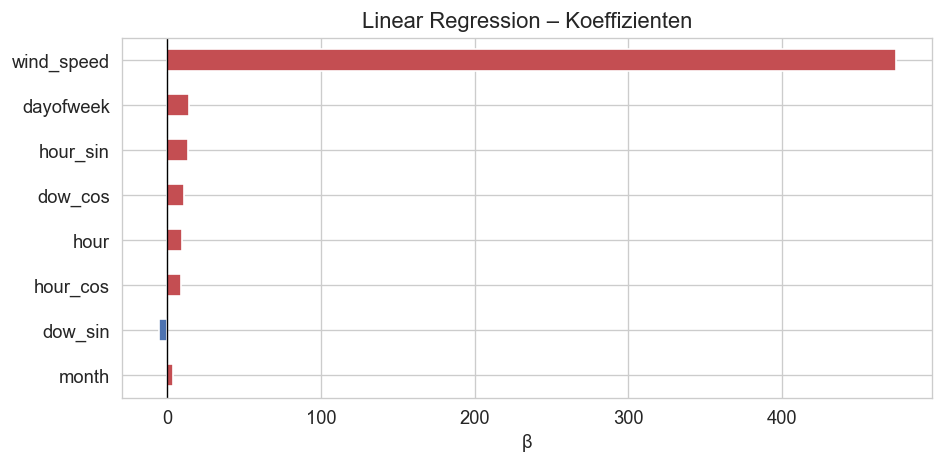

In [8]:
# Koeffizienten visualisieren (ohne Polynomial-Expansion)
lr_simple = LinearRegression().fit(X_tr_sc, y_train)
coef_df   = pd.Series(lr_simple.coef_, index=FEATURES).sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(FEATURES)*0.5)))
colors  = ['#C44E52' if c > 0 else '#4C72B0' for c in coef_df]
coef_df.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression – Koeffizienten')
ax.set_xlabel('β')
plt.tight_layout()
plt.savefig('../results/figures/09_lr_coefs.png', dpi=150, bbox_inches='tight')
plt.show()

## A4. Elastic Net

$$\hat{\beta}^{EN} = \arg\min_{\beta} \left\{ \|y - X\beta\|^2 + \lambda_1 \sum_j |\beta_j| + \lambda_2 \sum_j \beta_j^2 \right\}$$

L1 + L2 Regularisierung. Setzt irrelevante Features auf 0 (Sparsität) und stabilisiert korrelierte Features (Ridge).
Optimales α und l1_ratio via Kreuzvalidierung (KFold, shuffle=False für Zeitreihen).

In [9]:
kf = KFold(n_splits=5, shuffle=False)

en_model = ElasticNetCV(
    l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    alphas   = np.logspace(-4, 1, 30),
    cv       = kf,
    max_iter = 5000,
    n_jobs   = -1
)
en_model.fit(X_tr_sc, y_train)
y_pred_en = np.clip(en_model.predict(X_te_sc), 0, None)

results['Elastic Net']     = evaluate(y_test, y_pred_en)
predictions['Elastic Net'] = y_pred_en

n_active = (np.abs(en_model.coef_) > 1e-6).sum()
print(f'Optimales alpha:    {en_model.alpha_:.5f}')
print(f'Optimales l1_ratio: {en_model.l1_ratio_:.2f}')
print(f'Aktive Features:    {n_active}/{len(FEATURES)}')
print('Elastic Net:', results['Elastic Net'])

Optimales alpha:    10.00000
Optimales l1_ratio: 1.00
Aktive Features:    3/8
Elastic Net: {'RMSE': np.float64(423.222), 'MAE': 242.978, 'MAPE (%)': np.float64(725.549), 'Newsvendor Loss': np.float64(3208.352)}


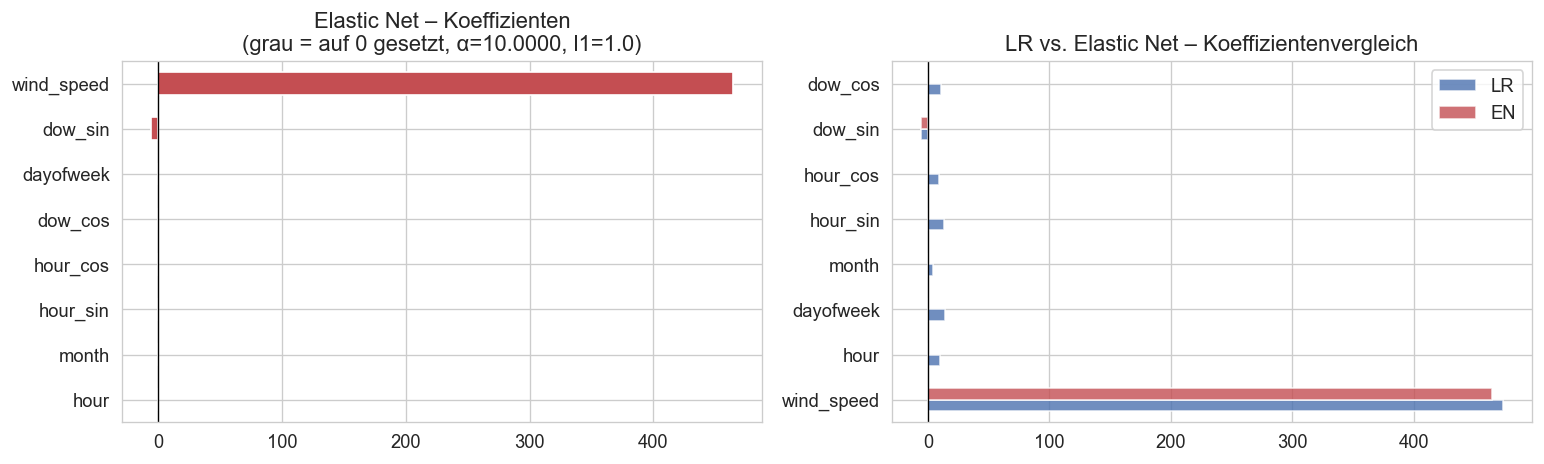

In [10]:
en_coefs = pd.Series(en_model.coef_, index=FEATURES).sort_values(key=abs, ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, max(4, len(FEATURES)*0.5)))

# EN Koeffizienten
colors_en = ['#C44E52' if abs(v) > 1e-6 else '#CCCCCC' for v in en_coefs]
en_coefs.plot(kind='barh', ax=axes[0], color=colors_en)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title(f'Elastic Net – Koeffizienten\n(grau = auf 0 gesetzt, α={en_model.alpha_:.4f}, l1={en_model.l1_ratio_:.1f})')

# LR vs EN Koeffizienten Vergleich
comp = pd.DataFrame({'LR': lr_simple.coef_, 'EN': en_model.coef_}, index=FEATURES)
comp.plot(kind='barh', ax=axes[1], color=['#4C72B0','#C44E52'], alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('LR vs. Elastic Net – Koeffizientenvergleich')

plt.tight_layout()
plt.savefig('../results/figures/09_en_coefs.png', dpi=150, bbox_inches='tight')
plt.show()

## A5. Random Forest

$$\hat{\omega} = \frac{1}{B}\sum_{b=1}^{B} T_b(x)$$

200 Entscheidungsbäume. Nichtlinear, robust, semi-interpretierbar via Feature Importance.
Kein Scaler nötig.

In [11]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = np.clip(rf_model.predict(X_test), 0, None)

results['Random Forest']     = evaluate(y_test, y_pred_rf)
predictions['Random Forest'] = y_pred_rf
print('Random Forest:', results['Random Forest'])

Random Forest: {'RMSE': np.float64(346.063), 'MAE': 145.182, 'MAPE (%)': np.float64(636.567), 'Newsvendor Loss': np.float64(1888.774)}


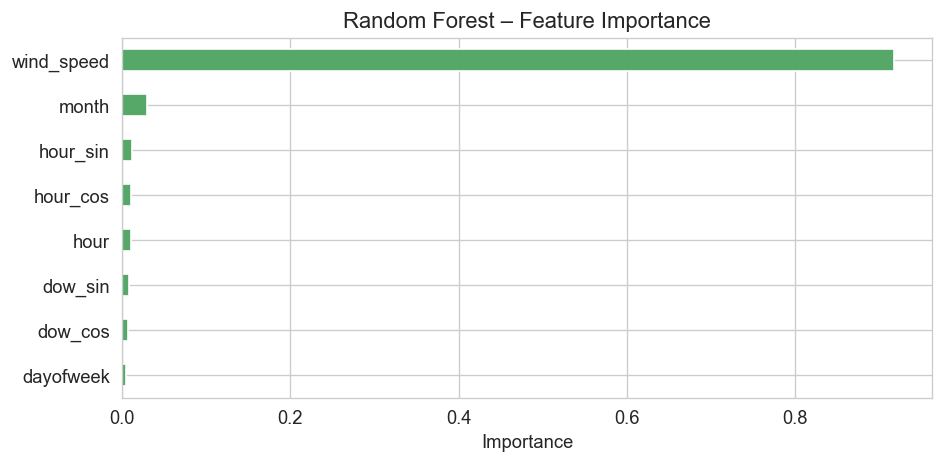

In [12]:
importance = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(FEATURES)*0.5)))
importance.plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Random Forest – Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('../results/figures/09_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## A6. Neural Network (MLP)

Architektur: `Input → 128 → 64 → 32 → 1` mit ReLU-Aktivierung.

Black Box – für XAI später SHAP verwenden. Skalierte Features Pflicht.

Epoch  20/100 – Loss: 33039.1673
Epoch  40/100 – Loss: 31115.0733
Epoch  60/100 – Loss: 30234.0322
Epoch  80/100 – Loss: 28163.0322
Epoch 100/100 – Loss: 26590.1362


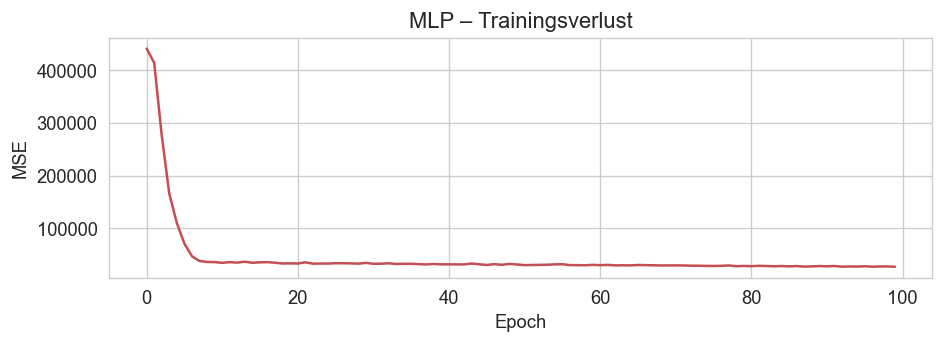

In [13]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, 32),         nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_tr_sc), torch.FloatTensor(y_train)),
    batch_size=128, shuffle=True
)
mlp       = MLP(X_tr_sc.shape[1])
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()

losses = []
for epoch in range(100):
    mlp.train()
    ep_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(mlp(xb), yb)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()
    losses.append(ep_loss / len(loader))
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}/100 – Loss: {losses[-1]:.4f}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, color='#C44E52')
ax.set_title('MLP – Trainingsverlust')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
plt.tight_layout()
plt.show()

In [14]:
mlp.eval()
with torch.no_grad():
    y_pred_mlp = mlp(torch.FloatTensor(X_te_sc)).numpy()
y_pred_mlp = np.clip(y_pred_mlp, 0, None)

results['Neural Network']     = evaluate(y_test, y_pred_mlp)
predictions['Neural Network'] = y_pred_mlp
print('Neural Network:', results['Neural Network'])

Neural Network: {'RMSE': np.float64(358.58), 'MAE': 165.448, 'MAPE (%)': np.float64(792.134), 'Newsvendor Loss': np.float64(2121.728)}


---
# Teil B – Windowing-based ML

**Idee:** Zeitreihe → Cross-Sectional Datensatz mit zeitverzögerten Lag-Features.

```
Zeitreihe:  [ω₁, ω₂, ω₃, ω₄, ω₅, ...]

Window W=3, Horizon H=1:
  Row 1:  X=[ω₁, ω₂, ω₃]  →  y=ω₄
  Row 2:  X=[ω₂, ω₃, ω₄]  →  y=ω₅
  ...
```

| Parameter | Wert | Bedeutung |
|-----------|------|----------|
| **W** | 24 | 24 Stunden Vergangenheit als Features |
| **H** | 1 | 1 Stunde voraus (nächste Stunde) |
| **S** | 1 | Jede Stunde ein Sample |

**Warum nur RF und EN?**
- RF: Vergleich mit/ohne Lag-Features – zeigt ob Autokorrelation hilft
- EN: Automatische Lag-Selektion via L1 – welche Lags sind wirklich wichtig?
- LR/MLP: Dopplung ohne neuen Erkenntnisgewinn
- LSTM/GBRT: Zu komplex, laut Protokoll kein aufwendiges Tuning

## B1. Windowing-Funktion und Datensatz

In [15]:
def create_windowed_dataset(series, W, H, S=1, extra_features=None):
    """
    Erstellt Cross-Sectional Datensatz aus Zeitreihe via Sliding Window.
    Args:
        series:         1D Zeitreihe (N,)
        W:              Window Size – Anzahl Lag-Features
        H:              Forecast Horizon
        S:              Skip / Schrittweite
        extra_features: optionale zusätzliche Features (N, F)
    Returns:
        X: (n_samples, W + F), y: (n_samples,)
    """
    X_list, y_list = [], []
    for i in range(0, len(series) - W - H + 1, S):
        lag_features = series[i : i + W]
        if extra_features is not None:
            extra = extra_features[i + W - 1]
            row   = np.concatenate([lag_features, extra])
        else:
            row = lag_features
        X_list.append(row)
        y_list.append(series[i + W + H - 1])
    return np.array(X_list), np.array(y_list)


# Parameter
W, H, S = 24, 1, 1

# Zusatz-Features (Windgeschwindigkeit, Zeitfeatures etc.)
extra_features = df[FEATURES].values if FEATURES else None

# Windowed Dataset
X_win, y_win = create_windowed_dataset(
    df[TARGET].values, W=W, H=H, S=S, extra_features=extra_features
)

# Lag-Feature-Namen
lag_names     = [f'lag_{i}' for i in range(1, W + 1)]
win_feat_names = lag_names + FEATURES

print(f'Windowed X: {X_win.shape}  ({W} Lags + {len(FEATURES)} Zusatz-Features)')
print(f'Windowed y: {y_win.shape}')

Windowed X: (6576, 32)  (24 Lags + 8 Zusatz-Features)
Windowed y: (6576,)


### B1.1 Train/Test Split für Windowed Dataset

In [16]:
sp_win    = int(len(X_win) * 0.8)
Xw_train, Xw_test = X_win[:sp_win], X_win[sp_win:]
yw_train, yw_test = y_win[:sp_win], y_win[sp_win:]

win_scaler  = StandardScaler()
Xw_tr_sc    = win_scaler.fit_transform(Xw_train)
Xw_te_sc    = win_scaler.transform(Xw_test)

print(f'Win-Train: {len(Xw_train)} Samples')
print(f'Win-Test:  {len(Xw_test)}  Samples')
print(f'Features:  {Xw_train.shape[1]} ({W} Lags + {len(FEATURES)} Zusatz)')

Win-Train: 5260 Samples
Win-Test:  1316  Samples
Features:  32 (24 Lags + 8 Zusatz)


## B2. Windowing + Random Forest

Derselbe RF-Algorithmus wie in A5 – aber jetzt mit **Lag-Features als Input**.

**Forschungsfrage:** Wird RF besser wenn er die letzten 24 Stunden direkt sieht?

In [17]:
rf_win = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_win.fit(Xw_train, yw_train)
y_pred_rf_win = np.clip(rf_win.predict(Xw_test), 0, None)

results['RF + Windowing']     = evaluate(yw_test, y_pred_rf_win)
predictions['RF + Windowing'] = y_pred_rf_win
print('RF + Windowing:', results['RF + Windowing'])
print()
print(f'Vergleich RF ohne Windowing: RMSE={results["Random Forest"]["RMSE"]}')
print(f'Vergleich RF mit  Windowing: RMSE={results["RF + Windowing"]["RMSE"]}')

RF + Windowing: {'RMSE': np.float64(462.424), 'MAE': 265.691, 'MAPE (%)': np.float64(795.351), 'Newsvendor Loss': np.float64(3473.498)}

Vergleich RF ohne Windowing: RMSE=346.063
Vergleich RF mit  Windowing: RMSE=462.424


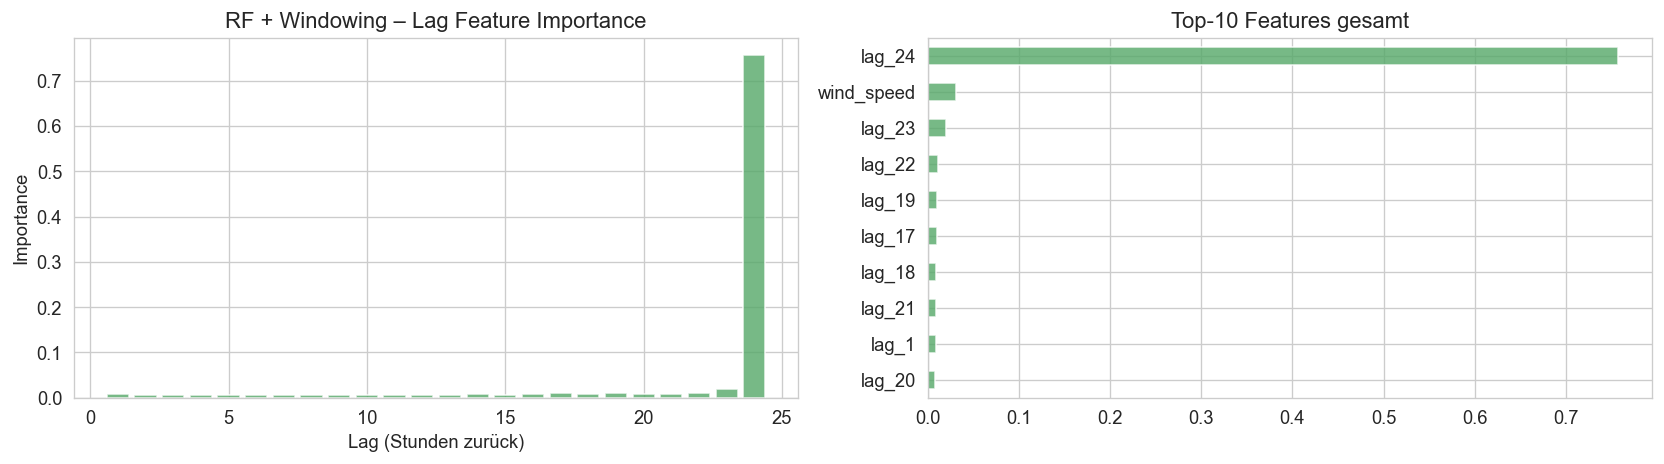

In [18]:
# Welche Lags sind am wichtigsten?
win_importance = pd.Series(rf_win.feature_importances_, index=win_feat_names)
lag_imp        = win_importance[lag_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(1, W + 1), lag_imp.values, color='#55A868', alpha=0.8)
axes[0].set_title('RF + Windowing – Lag Feature Importance')
axes[0].set_xlabel('Lag (Stunden zurück)')
axes[0].set_ylabel('Importance')

# Top-10 Features gesamt
win_importance.sort_values(ascending=True).tail(10).plot(
    kind='barh', ax=axes[1], color='#55A868', alpha=0.8)
axes[1].set_title('Top-10 Features gesamt')

plt.tight_layout()
plt.savefig('../results/figures/09_rf_win_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## B3. Windowing + Elastic Net

Elastic Net auf Lag-Features: L1 setzt irrelevante Lags exakt auf 0.

**Forschungsfrage:** Welche der 24 vergangenen Stunden sind wirklich informativ?

Besonders spannend: Benachbarte Lags sind hochkorreliert → EN selektiert Gruppen gemeinsam.

In [19]:
kf_win = KFold(n_splits=5, shuffle=False)

en_win = ElasticNetCV(
    l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    alphas   = np.logspace(-4, 1, 30),
    cv       = kf_win,
    max_iter = 5000,
    n_jobs   = -1
)
en_win.fit(Xw_tr_sc, yw_train)
y_pred_en_win = np.clip(en_win.predict(Xw_te_sc), 0, None)

results['EN + Windowing']     = evaluate(yw_test, y_pred_en_win)
predictions['EN + Windowing'] = y_pred_en_win

n_active_lags = (np.abs(en_win.coef_[:W]) > 1e-6).sum()
print(f'Optimales alpha:    {en_win.alpha_:.5f}')
print(f'Optimales l1_ratio: {en_win.l1_ratio_:.2f}')
print(f'Aktive Lags:        {n_active_lags}/{W}')
print(f'Aktive Features ges:{(np.abs(en_win.coef_) > 1e-6).sum()}/{Xw_train.shape[1]}')
print('EN + Windowing:', results['EN + Windowing'])

Optimales alpha:    4.52035
Optimales l1_ratio: 1.00
Aktive Lags:        6/24
Aktive Features ges:10/32
EN + Windowing: {'RMSE': np.float64(345.093), 'MAE': 195.639, 'MAPE (%)': np.float64(548.493), 'Newsvendor Loss': np.float64(2514.013)}


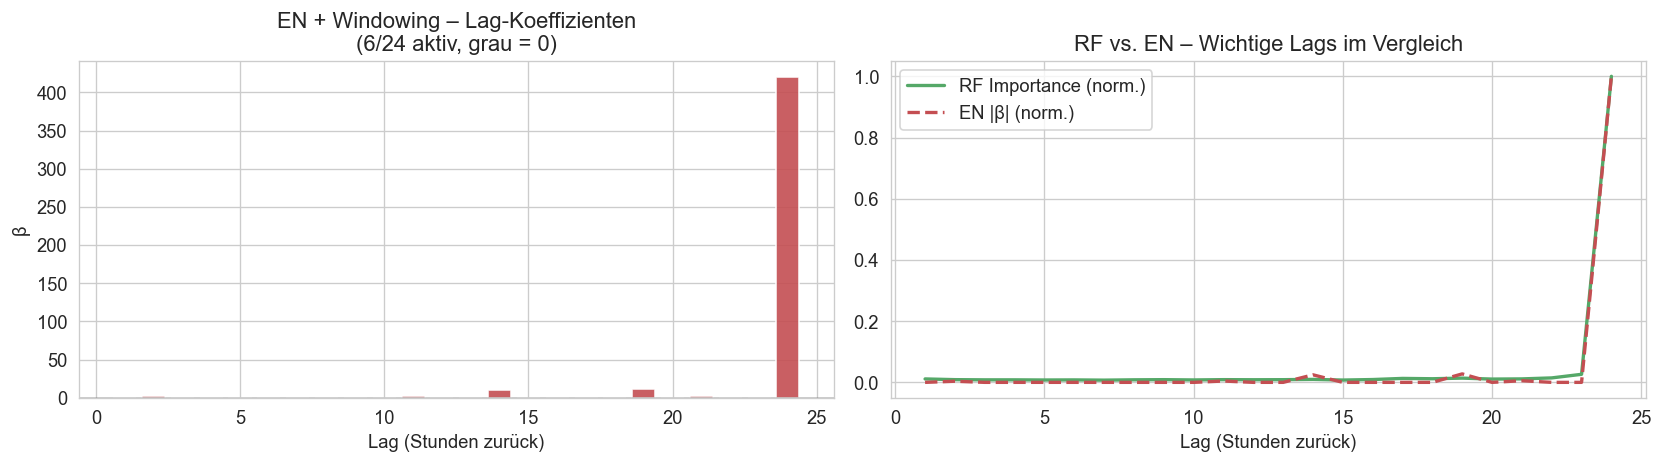

In [20]:
en_lag_coefs = pd.Series(en_win.coef_[:W], index=lag_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Lag-Koeffizienten: aktiv vs. inaktiv
colors_lag = ['#C44E52' if abs(v) > 1e-6 else '#DDDDDD' for v in en_lag_coefs]
axes[0].bar(range(1, W + 1), en_lag_coefs.values, color=colors_lag, alpha=0.9)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title(f'EN + Windowing – Lag-Koeffizienten\n({n_active_lags}/{W} aktiv, grau = 0)')
axes[0].set_xlabel('Lag (Stunden zurück)')
axes[0].set_ylabel('β')

# Vergleich: RF Lag-Importance vs EN Lag-Koeffizienten (normiert)
rf_imp_norm = lag_imp / lag_imp.max()
en_abs_norm = en_lag_coefs.abs() / (en_lag_coefs.abs().max() + 1e-10)
axes[1].plot(range(1, W+1), rf_imp_norm.values,  label='RF Importance (norm.)',  color='#55A868', linewidth=2)
axes[1].plot(range(1, W+1), en_abs_norm.values,  label='EN |β| (norm.)',         color='#C44E52', linewidth=2, linestyle='--')
axes[1].set_title('RF vs. EN – Wichtige Lags im Vergleich')
axes[1].set_xlabel('Lag (Stunden zurück)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/09_en_win_lags.png', dpi=150, bbox_inches='tight')
plt.show()

## B4. Sensitivitätsanalyse: Window Size W

W ist willkürlich – wie stark beeinflusst es die Performance?
Proxy: Random Forest (schnell) für verschiedene W-Werte.

W=  6: RMSE=499.83  NV-Loss=3502.63
W= 12: RMSE=490.30  NV-Loss=3583.95
W= 24: RMSE=494.61  NV-Loss=3681.71
W= 48: RMSE=482.99  NV-Loss=3571.53
W= 72: RMSE=460.04  NV-Loss=3504.59


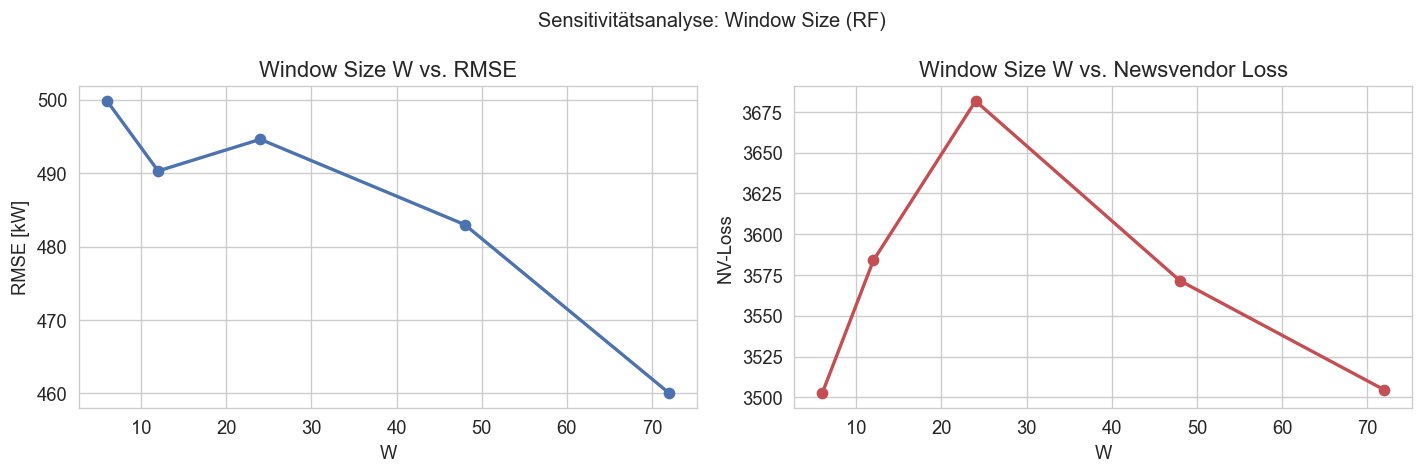

In [21]:
W_values    = [6, 12, 24, 48, 72]
sensitivity = []

for w in W_values:
    X_w, y_w = create_windowed_dataset(df[TARGET].values, W=w, H=1, S=1)
    sp_w     = int(len(X_w) * 0.8)
    rf_tmp   = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_tmp.fit(X_w[:sp_w], y_w[:sp_w])
    y_tmp    = rf_tmp.predict(X_w[sp_w:])
    sensitivity.append({
        'W': w,
        'RMSE':     round(rmse(y_w[sp_w:], y_tmp), 2),
        'NV-Loss':  round(newsvendor_loss(y_w[sp_w:], y_tmp), 2)
    })
    print(f'W={w:3d}: RMSE={sensitivity[-1]["RMSE"]:.2f}  NV-Loss={sensitivity[-1]["NV-Loss"]:.2f}')

df_sens = pd.DataFrame(sensitivity)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_sens['W'], df_sens['RMSE'],    marker='o', color='#4C72B0', linewidth=2)
axes[0].set_title('Window Size W vs. RMSE')
axes[0].set_xlabel('W')
axes[0].set_ylabel('RMSE [kW]')
axes[1].plot(df_sens['W'], df_sens['NV-Loss'], marker='o', color='#C44E52', linewidth=2)
axes[1].set_title('Window Size W vs. Newsvendor Loss')
axes[1].set_xlabel('W')
axes[1].set_ylabel('NV-Loss')
plt.suptitle('Sensitivitätsanalyse: Window Size (RF)', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/09_window_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Teil C – Gesamtvergleich aller Modelle

Achtung: Windowing-Modelle haben leicht unterschiedliche Test-Sets (fehlende erste W Samples).
Für fairen Vergleich werden beide Subsets separat ausgewiesen.

## C1. Metriken-Tabelle

In [22]:
# Teil A Ergebnisse (Point Forecasts)
part_a = ['Persistence','Mean Forecast','Linear Regression','Elastic Net','Random Forest','Neural Network']
df_a   = pd.DataFrame({k: results[k] for k in part_a}).T.astype(float).round(3)

# Teil B Ergebnisse (Windowing)
part_b = ['RF + Windowing','EN + Windowing']
df_b   = pd.DataFrame({k: results[k] for k in part_b}).T.astype(float).round(3)

print('── Teil A: Point Forecasts ────────────────────────────────')
print(df_a.to_string())
print()
print('── Teil B: Windowing ML ───────────────────────────────────')
print(df_b.to_string())
print()
print('Bestes RMSE (A):            ', df_a['RMSE'].idxmin())
print('Bestes Newsvendor Loss (A): ', df_a['Newsvendor Loss'].idxmin())
print('Bestes RMSE (B):            ', df_b['RMSE'].idxmin())

df_a.to_csv('../results/tables/09_point_forecast_metrics.csv')
df_b.to_csv('../results/tables/09_windowing_metrics.csv')
print('\nGespeichert in results/tables/')

── Teil A: Point Forecasts ────────────────────────────────
                      RMSE      MAE  MAPE (%)  Newsvendor Loss
Persistence        924.754  601.019  3428.567         7486.420
Mean Forecast      877.060  580.094  3293.619         7824.263
Linear Regression  376.829  178.196   769.867         2185.226
Elastic Net        423.222  242.978   725.549         3208.352
Random Forest      346.063  145.182   636.567         1888.774
Neural Network     358.580  165.448   792.134         2121.728

── Teil B: Windowing ML ───────────────────────────────────
                   RMSE      MAE  MAPE (%)  Newsvendor Loss
RF + Windowing  462.424  265.691   795.351         3473.498
EN + Windowing  345.093  195.639   548.493         2514.013

Bestes RMSE (A):             Random Forest
Bestes Newsvendor Loss (A):  Random Forest
Bestes RMSE (B):             EN + Windowing

Gespeichert in results/tables/


## C2. Visualisierung

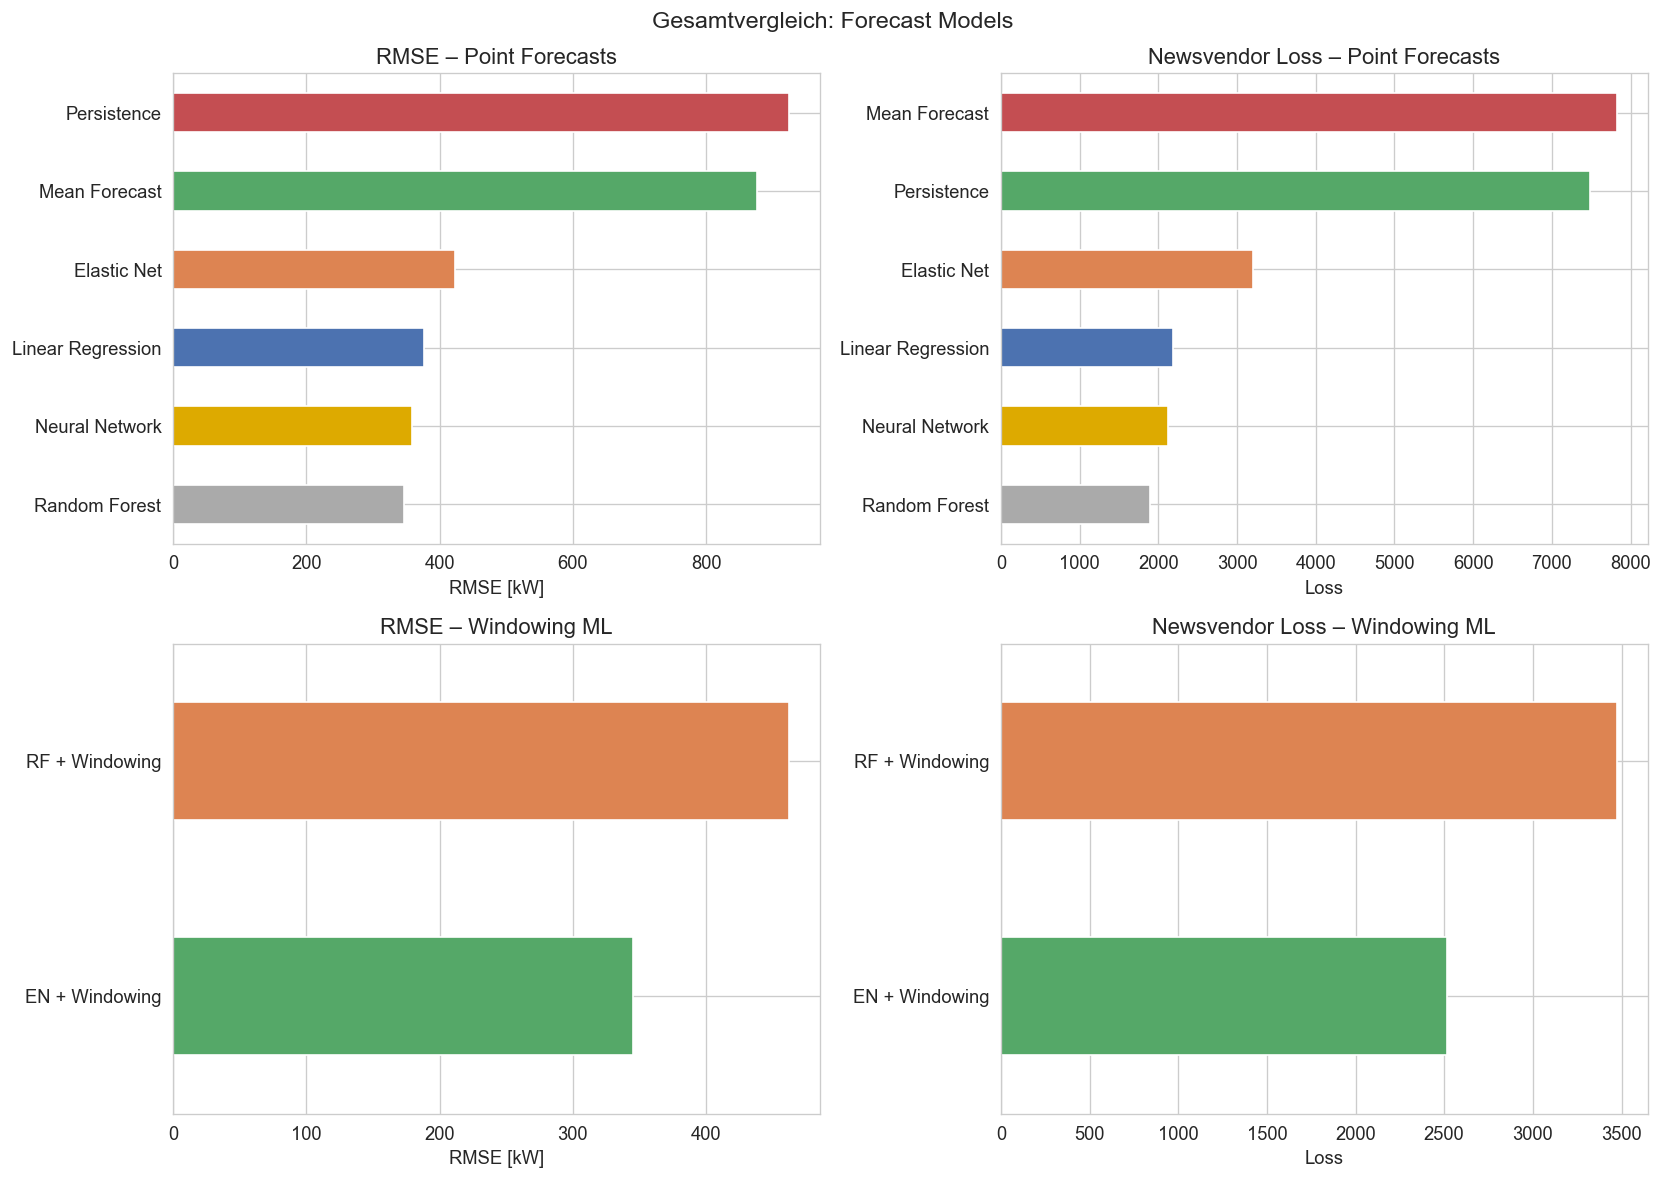

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors_a = ['#AAAAAA','#DDAA00','#4C72B0','#DD8452','#55A868','#C44E52']
colors_b = ['#55A868','#DD8452']

# RMSE Teil A
df_a['RMSE'].sort_values().plot(kind='barh', ax=axes[0,0], color=colors_a, edgecolor='white')
axes[0,0].set_title('RMSE – Point Forecasts')
axes[0,0].set_xlabel('RMSE [kW]')

# Newsvendor Loss Teil A
df_a['Newsvendor Loss'].sort_values().plot(kind='barh', ax=axes[0,1], color=colors_a, edgecolor='white')
axes[0,1].set_title('Newsvendor Loss – Point Forecasts')
axes[0,1].set_xlabel('Loss')

# RMSE Teil B
df_b['RMSE'].sort_values().plot(kind='barh', ax=axes[1,0], color=colors_b, edgecolor='white')
axes[1,0].set_title('RMSE – Windowing ML')
axes[1,0].set_xlabel('RMSE [kW]')

# Newsvendor Loss Teil B
df_b['Newsvendor Loss'].sort_values().plot(kind='barh', ax=axes[1,1], color=colors_b, edgecolor='white')
axes[1,1].set_title('Newsvendor Loss – Windowing ML')
axes[1,1].set_xlabel('Loss')

plt.suptitle('Gesamtvergleich: Forecast Models', fontsize=14)
plt.tight_layout()
plt.savefig('../results/figures/09_model_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

## C3. Forecast vs. Actual – alle Modelle (2 Wochen)

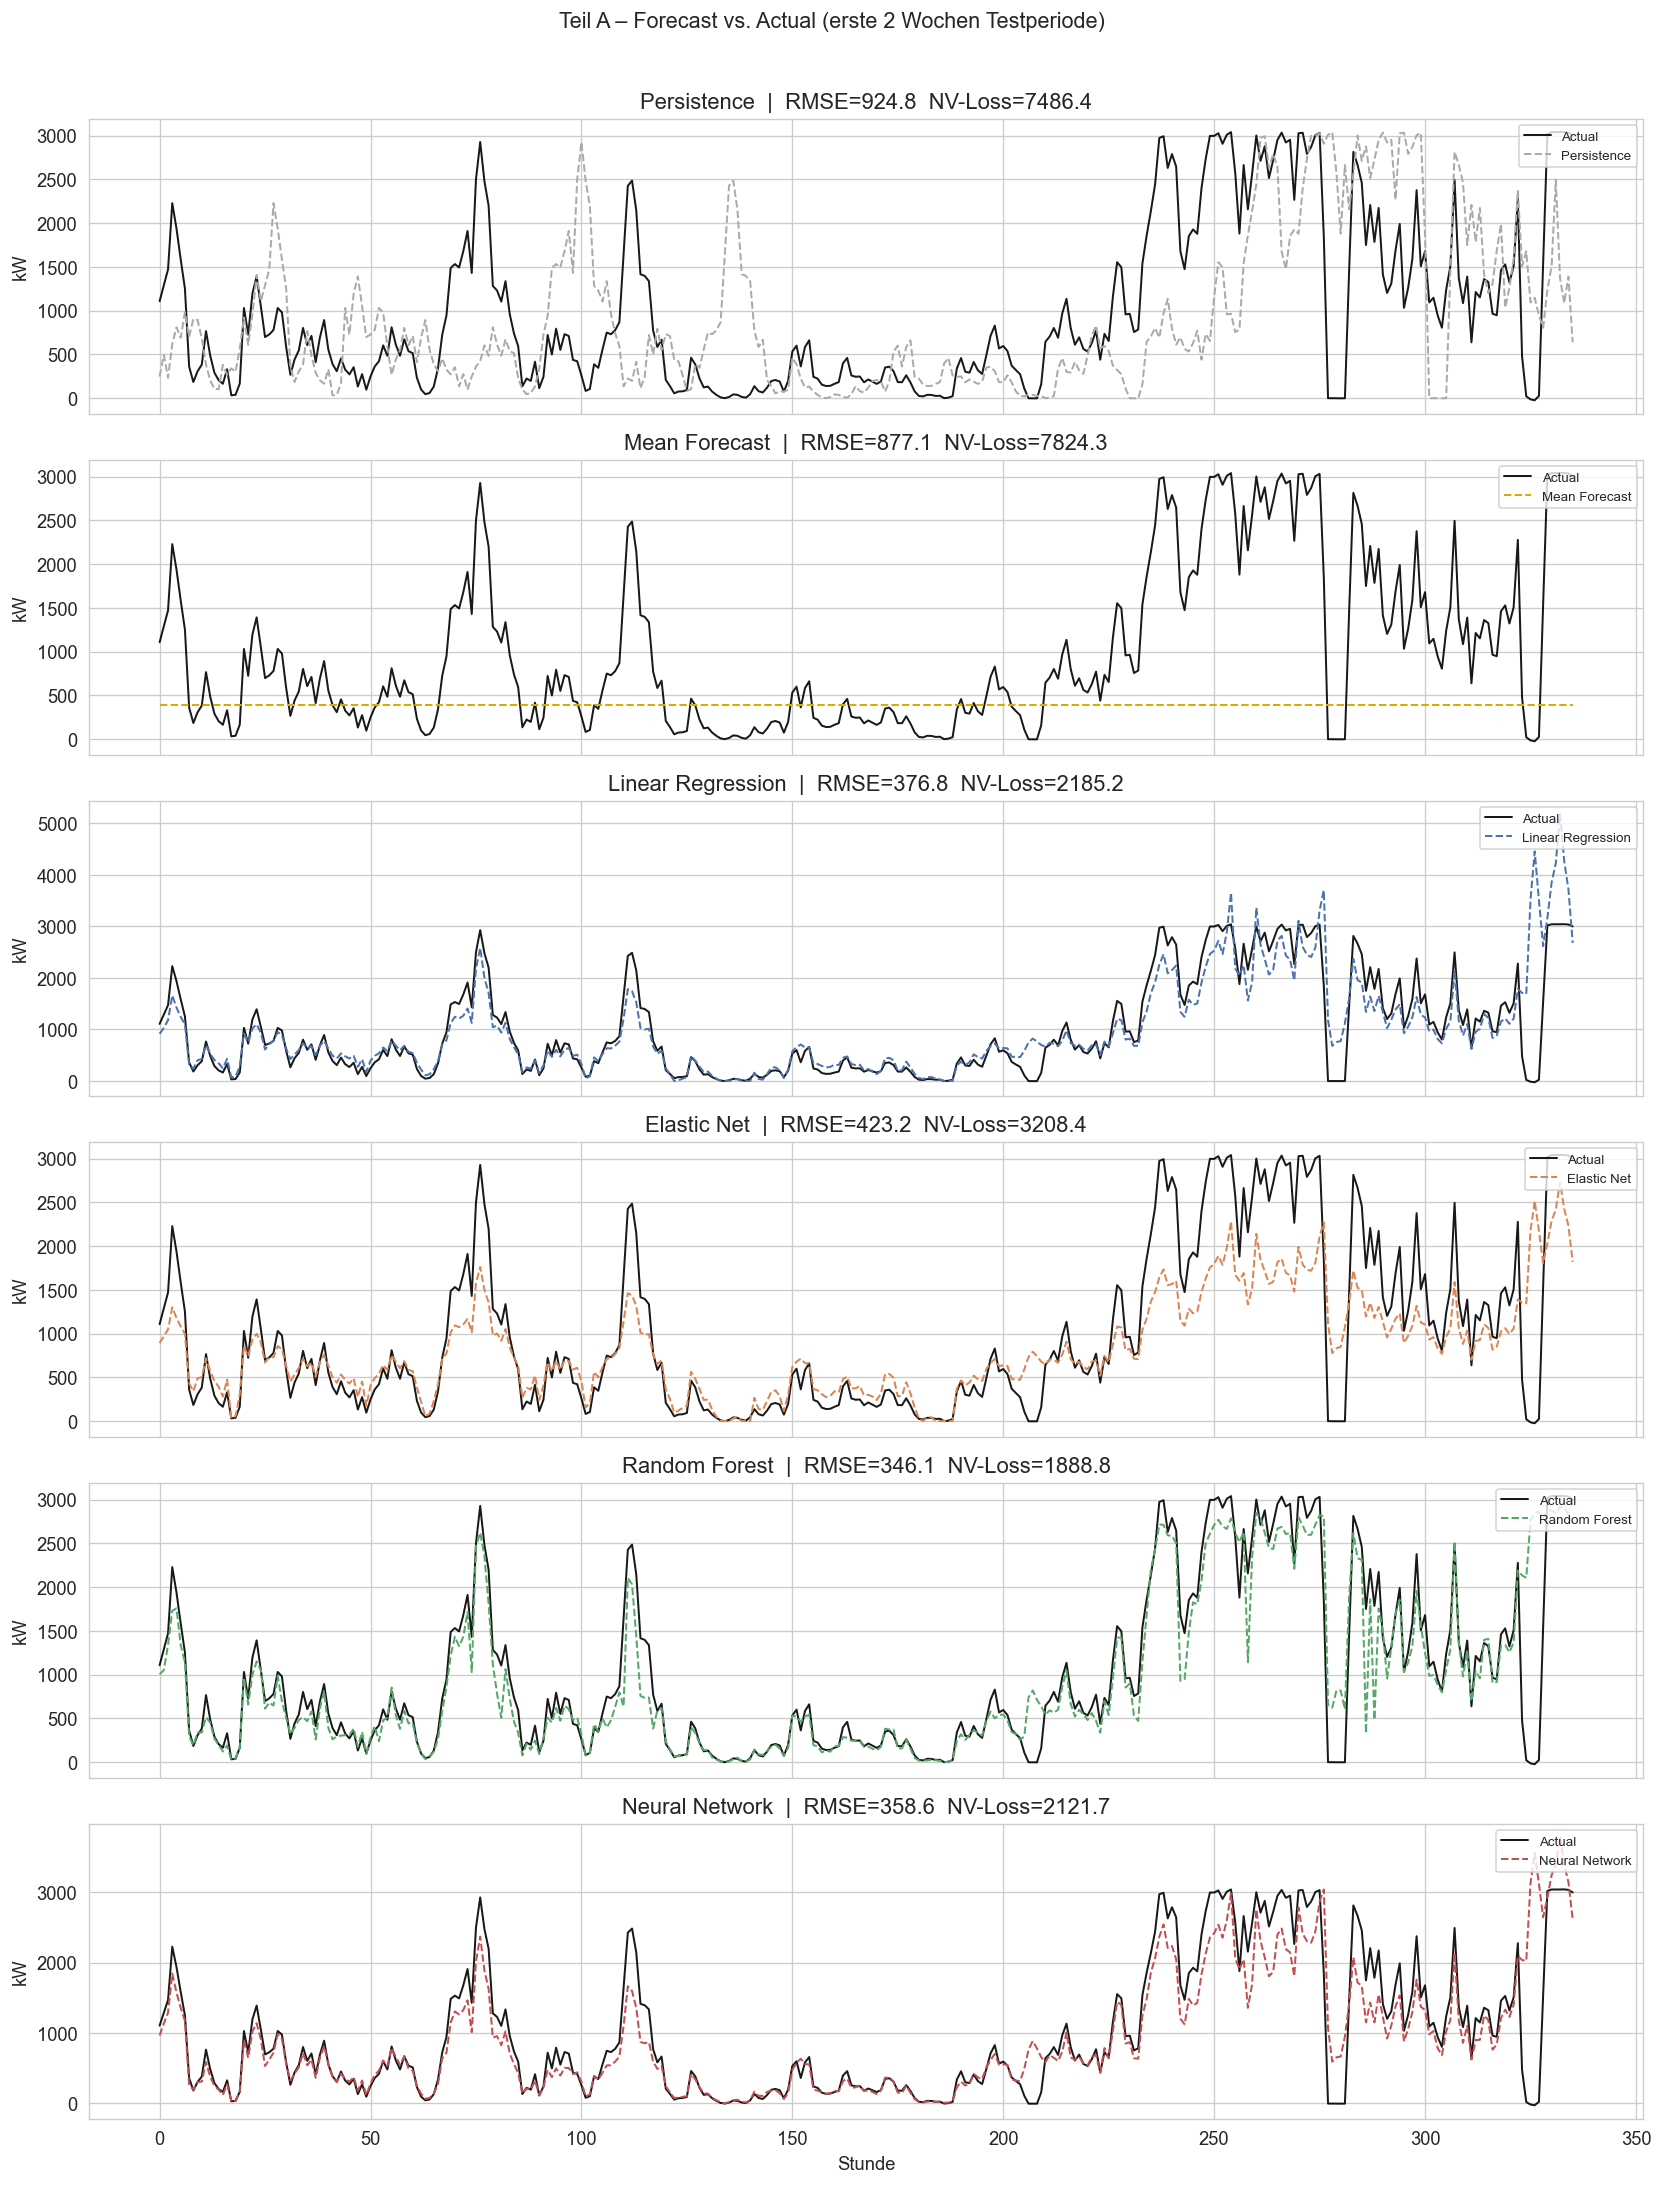

In [24]:
N_PLOT = 336
colors_map = {
    'Persistence':      '#AAAAAA',
    'Mean Forecast':    '#DDAA00',
    'Linear Regression':'#4C72B0',
    'Elastic Net':      '#DD8452',
    'Random Forest':    '#55A868',
    'Neural Network':   '#C44E52',
    'RF + Windowing':   '#2ca02c',
    'EN + Windowing':   '#ff7f0e',
}

# Für fairen Vergleich: Windowing-Predictions haben anderen y_test!
# Daher separat plotten
fig, axes = plt.subplots(len(part_a), 1, figsize=(14, 3*len(part_a)), sharex=True)
for ax, name in zip(axes, part_a):
    y_pred = predictions[name]
    ax.plot(y_test[:N_PLOT],  label='Actual', color='black', linewidth=1.2, alpha=0.9)
    ax.plot(y_pred[:N_PLOT],  label=name,     color=colors_map[name], linewidth=1.2, linestyle='--')
    ax.set_ylabel('kW')
    ax.set_title(f"{name}  |  RMSE={results[name]['RMSE']:.1f}  NV-Loss={results[name]['Newsvendor Loss']:.1f}")
    ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Stunde')
plt.suptitle('Teil A – Forecast vs. Actual (erste 2 Wochen Testperiode)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/09_forecast_vs_actual_A.png', dpi=150, bbox_inches='tight')
plt.show()

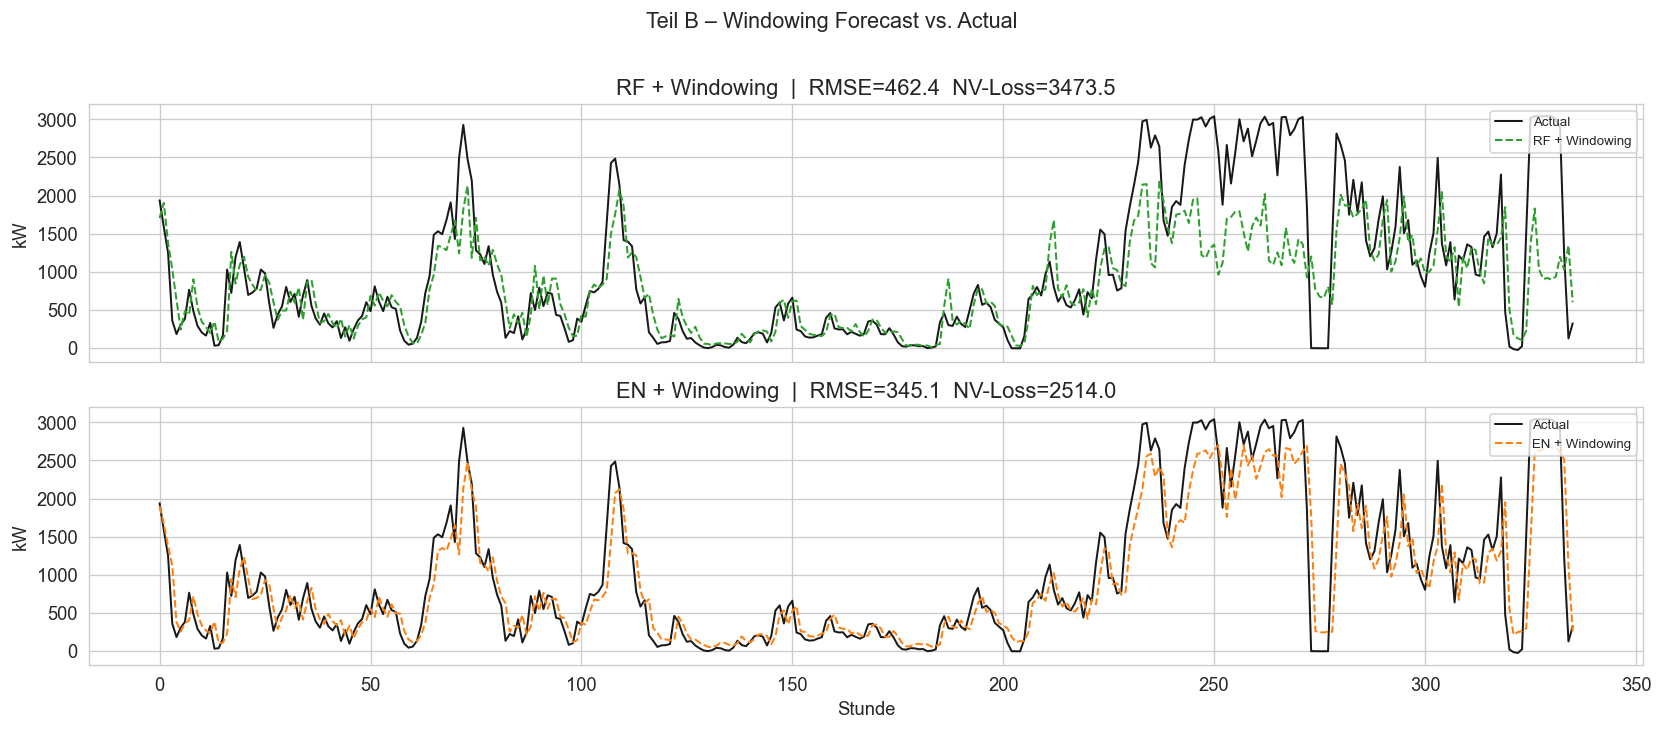

In [25]:
fig, axes = plt.subplots(len(part_b), 1, figsize=(14, 3*len(part_b)), sharex=True)
for ax, name in zip(axes, part_b):
    y_pred = predictions[name]
    ax.plot(yw_test[:N_PLOT],  label='Actual', color='black', linewidth=1.2, alpha=0.9)
    ax.plot(y_pred[:N_PLOT],   label=name,     color=colors_map[name], linewidth=1.2, linestyle='--')
    ax.set_ylabel('kW')
    ax.set_title(f"{name}  |  RMSE={results[name]['RMSE']:.1f}  NV-Loss={results[name]['Newsvendor Loss']:.1f}")
    ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Stunde')
plt.suptitle('Teil B – Windowing Forecast vs. Actual', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/09_forecast_vs_actual_B.png', dpi=150, bbox_inches='tight')
plt.show()

## C4. Newsvendor-Bidding Zusammenfassung

Point Forecasts → direktes Gebot: **y_bid = ŷ**

Optimales Gebot wäre: y* = F⁻¹(τ), τ = c_under / (c_under + c_over)

→ Für bessere Gebote: Quantile Regression (nächstes Notebook)

In [26]:
C_OVER, C_UNDER = 10.0, 15.0
tau = C_UNDER / (C_UNDER + C_OVER)
print(f'c_under={C_UNDER}, c_over={C_OVER} → tau={tau:.3f}')
print(f'Optimales Gebot = {tau*100:.0f}%-Quantil der Produktionsverteilung')
print()
print('── Newsvendor Loss Ranking (Teil A) ─────────────────────')
for name in sorted(part_a, key=lambda n: results[n]['Newsvendor Loss']):
    print(f'  {name:<22}: {results[name]["Newsvendor Loss"]:.3f}')
print()
print('── Newsvendor Loss Ranking (Teil B) ─────────────────────')
for name in sorted(part_b, key=lambda n: results[n]['Newsvendor Loss']):
    print(f'  {name:<22}: {results[name]["Newsvendor Loss"]:.3f}')

c_under=15.0, c_over=10.0 → tau=0.600
Optimales Gebot = 60%-Quantil der Produktionsverteilung

── Newsvendor Loss Ranking (Teil A) ─────────────────────
  Random Forest         : 1888.774
  Neural Network        : 2121.728
  Linear Regression     : 2185.226
  Elastic Net           : 3208.352
  Persistence           : 7486.420
  Mean Forecast         : 7824.263

── Newsvendor Loss Ranking (Teil B) ─────────────────────
  EN + Windowing        : 2514.013
  RF + Windowing        : 3473.498


## C5. Zusammenfassung & Key Insights

### Teil A – Point Forecasts
1. **Persistence** ist Industriestandard – jedes ML-Modell muss es schlagen
2. **Mean Forecast** ist Untergrenze – Modell mit schlechterem Score hat ein Problem
3. **Linear Regression** interpretierbarste ML-Baseline – Koeffizienten direkt lesbar
4. **Elastic Net** selektiert automatisch relevante Features → sparsames Modell
5. **Random Forest** profitiert von Nichtlinearität der Windkurve (P ~ v³)
6. **Neural Network** maximale Flexibilität, Black Box → SHAP für XAI

### Teil B – Windowing ML
7. **RF + Windowing**: Zeigt ob Autokorrelation der Zeitreihe zusätzlichen Nutzen bringt
8. **EN + Windowing**: Welche der 24 Lags sind wirklich informativ? L1 selektiert automatisch
9. **W ist willkürlich** – Sensitivitätsanalyse zeigt den Einfluss von W auf Performance

### Offene TODOs
- [ ] c_under / c_over aus echten Marktpreisen ableiten
- [ ] Quantile Regression für direktes τ-Gebot (10_quantile_regression.ipynb)
- [ ] SHAP-Analyse für RF und NN (05_xai_analysis.ipynb)
- [ ] Optimales W aus Sensitivitätsanalyse für finale Modelle verwenden